In [29]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')
from schema4one.backend.model_np import FeedForwardCells, RecurrentCells, PlaceCells
from schema4one.backend.utils import get_default_hp
from sklearn.decomposition import PCA

In [30]:
# initialize network
hp = get_default_hp('6pa')

seed = 0

hp['ract'] = 'tanh'
hp['tstep'] = 20
hp['nrnn'] = 1024
hp['npc'] = 7

x_vals = np.linspace(-0.8,0.8,21)
traj = np.meshgrid(x_vals, x_vals)
traj = np.stack(traj, axis=-1).reshape(-1, 2)
pc = PlaceCells(hp)
pc_act = np.array([pc.sense(xy) for xy in traj])
time = len(pc_act)

np.random.seed(seed)
ncues = 6
gain = 3
cues = np.eye(ncues) * gain
ff = FeedForwardCells(hp, ninput=ncues+hp['npc']**2)
res = RecurrentCells(hp, ninput=ncues+hp['npc']**2)



In [31]:
ff_act = np.zeros((ncues, time, hp['nrnn']))
for c, cue in enumerate(cues):

    for t in range(time):
        input_vec = np.concatenate([cue, pc_act[t]])
        ff_act[c, t] = ff.process(input_vec[None, :])

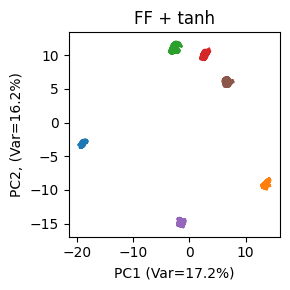

In [45]:
# plot PCA
pca = PCA(n_components=2)
ff_reshape = ff_act.reshape(-1, hp['nrnn'])
ff_act_2d = pca.fit_transform(ff_reshape)
ff_act_2d = ff_act_2d.reshape(ncues, time, 2)

plt.figure(figsize=(3, 3))
for c in range(ncues):
    plt.plot(ff_act_2d[c, :, 0], ff_act_2d[c, :, 1], label=f'Cue {c+1}')
plt.xlabel('PC1 (Var={:.1f}%)'.format(pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2, (Var={:.1f}%)'.format(pca.explained_variance_ratio_[1]*100))
plt.title(f'FF + {hp['ract']}')
# plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Eigenspectrum of FF + tanh')

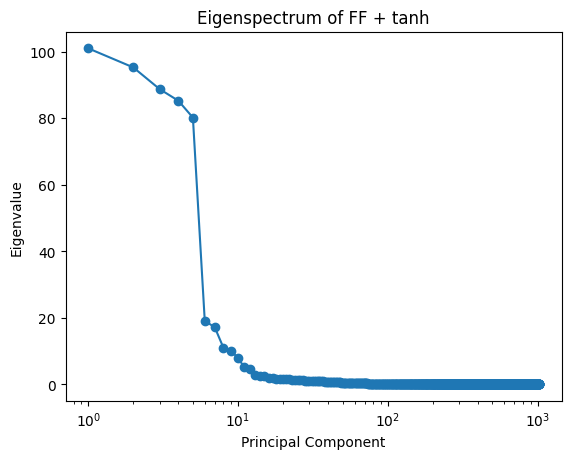

In [ ]:
# get full eigenvalues and vectors
np.eigvals, np.eigvecs = np.linalg.eig(np.cov(ff_reshape.T))

plt.figure(figsize=(3, 3))
plt.plot(np.arange(1, hp['nrnn']+1), np.eigvals, marker='o')
plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title(f'Eigenspectrum of FF + {hp['ract']}')